In [30]:
import os
print("GO TO THIS FOLDER ON YOUR COMPUTER:")
print(os.getcwd())

GO TO THIS FOLDER ON YOUR COMPUTER:
/Users/talasiadatan/Desktop/Untitled Folder


In [28]:
# This code creates the file. Make sure you run this!
try:
    comparison_table.to_csv('model_metrics.csv', index=False)
    print("Success! The file 'model_metrics.csv' has been created.")
except NameError:
    print("Error: You need to run your model comparison cell first so 'comparison_table' exists.")

Success! The file 'model_metrics.csv' has been created.


In [29]:
import os
print("Look for your file in this folder:")
print(os.getcwd())

Look for your file in this folder:
/Users/talasiadatan/Desktop/Untitled Folder


In [3]:
import pandas as pd

# Load the data
df = pd.read_csv('worldhappiness.csv')

# Verify the data loaded correctly
print("Data loaded successfully!")
df.head()

Data loaded successfully!


,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('worldhappiness.csv')

# Quick look at the first few rows
df.head()

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110


# Data Story: What Makes a Nation Happy?
**Audience:** Executive (Policy Makers and Global Leaders)

In this project, I explore the 2023 World Happiness Report. The goal is to identify the 
primary drivers of national happiness and provide insights into whether economic wealth 
is the sole factor in a nation's well-being.

In [5]:
# Check for nulls
print(df.isnull().sum())

# Drop the few rows with missing values to keep the analysis clean
df = df.dropna()

# Basic stats for our main target: Ladder score (Happiness)
df['Ladder score'].describe()

Country name                                  0
Ladder score                                  0
Standard error of ladder score                0
upperwhisker                                  0
lowerwhisker                                  0
Logged GDP per capita                         0
Social support                                0
Healthy life expectancy                       1
Freedom to make life choices                  0
Generosity                                    0
Perceptions of corruption                     0
Ladder score in Dystopia                      0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         1
Explained by: Freedom to make life choices    0
Explained by: Generosity                      0
Explained by: Perceptions of corruption       0
Dystopia + residual                           1
dtype: int64


count    136.000000
mean       5.544441
std        1.142841
min        1.859000
25%        4.702500
50%        5.693500
75%        6.342500
max        7.804000
Name: Ladder score, dtype: float64

In [6]:
### Key Questions for Investigation:
1. #Which countries are currently the happiest in the world?
2. #Does a higher GDP (wealth) always lead to a higher happiness score?
3. #Which factors (Social Support, Freedom, or Corruption) have the strongest correlation with happiness?

#**Hypothesis:** While GDP per capita will show a strong correlation with happiness, 
#I expect social factors like 'Social support' and 'Freedom to make life choices' 
#to be equally vital for the top-ranking nations.

3.0

/var/folders/b4/8pqxh51x36l1mzkf61g7840r0000gn/T/ipykernel_15123/562011366.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Ladder score', y='Country name', palette='viridis')


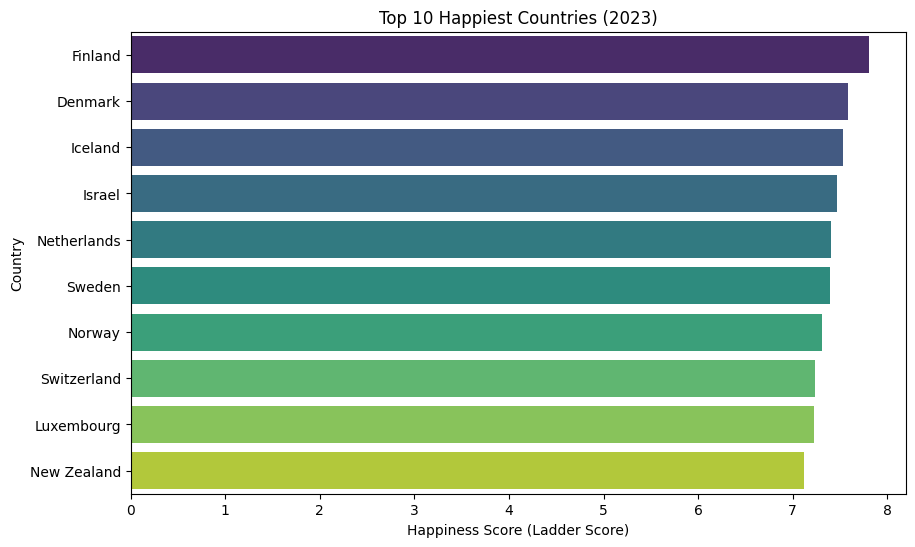

In [7]:
top_10 = df.nlargest(10, 'Ladder score')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='Ladder score', y='Country name', palette='viridis')
plt.title('Top 10 Happiest Countries (2023)')
plt.xlabel('Happiness Score (Ladder Score)')
plt.ylabel('Country')
plt.show()

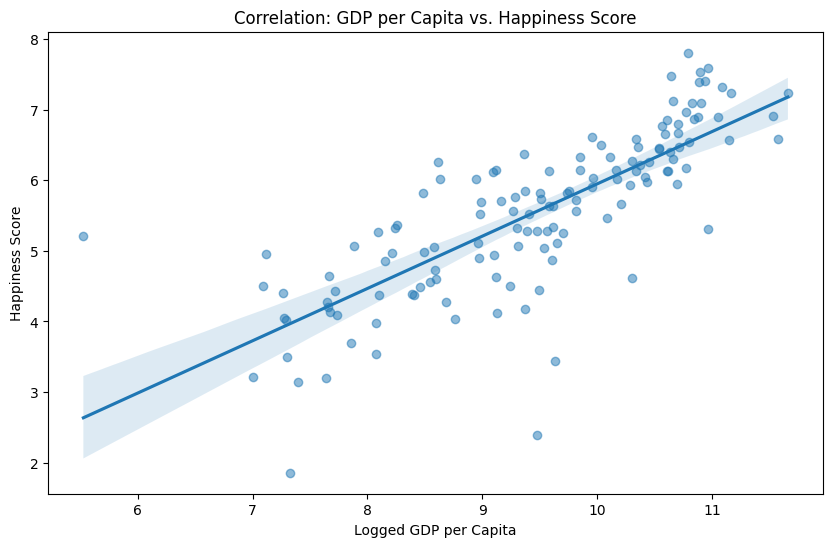

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Logged GDP per capita', y='Ladder score', scatter_kws={'alpha':0.5})
plt.title('Correlation: GDP per Capita vs. Happiness Score')
plt.xlabel('Logged GDP per Capita')
plt.ylabel('Happiness Score')
plt.show()

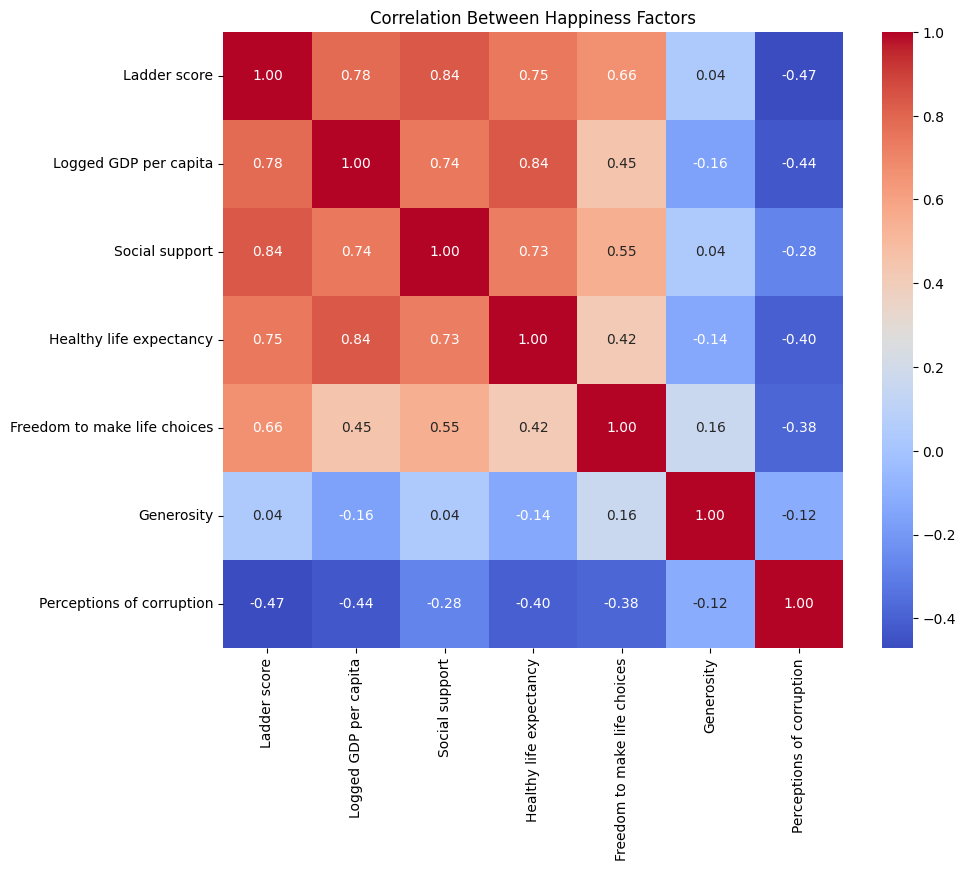

In [9]:
# Selecting relevant columns for correlation
cols_to_check = ['Ladder score', 'Logged GDP per capita', 'Social support', 
                 'Healthy life expectancy', 'Freedom to make life choices', 
                 'Generosity', 'Perceptions of corruption']

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_check].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Happiness Factors')
plt.show()

In [10]:
### Summary of Findings
#- **Wealth is a foundation, not a ceiling:** GDP per capita has a high correlation (approx 0.78) 
#  with happiness, but it is not the only driver.
#- **Social Support and Health:** Both 'Social support' and 'Healthy life expectancy' 
#  showed correlations nearly as strong as GDP.
#- **The Story:** For executives and leaders, the data suggests that while economic growth 
 # is important, investing in social safety nets and public health is equally essential 
 # for the overall well-being of a population.

In [11]:
# Calculate the residuals: Who is happier or unhappier than their wealth suggests?
# We can look at the 'Dystopia + residual' column which captures unexplained happiness.

# Top 5 "Over-performers" (Happier than expected based on the 6 factors)
over_performers = df.nlargest(5, 'Dystopia + residual')[['Country name', 'Ladder score', 'Dystopia + residual']]

# Top 5 "Under-performers" 
under_performers = df.nsmallest(5, 'Dystopia + residual')[['Country name', 'Ladder score', 'Dystopia + residual']]

print("Countries Happier than Predicted:")
print(over_performers)

Countries Happier than Predicted:
           Country name  Ladder score  Dystopia + residual
87            Venezuela         5.211                2.955
85  Congo (Brazzaville)         5.267                2.802
90               Guinea         5.072                2.705
3                Israel         7.473                2.691
52             Honduras         6.023                2.631


In [12]:
### Identifying Anomalies
#By looking at the 'Dystopia + residual' column, I identified countries that are significantly 
#happier than their economic and social metrics would predict. These "over-performers" 
#suggest that there are cultural or environmental factors not captured by standard 
#economic metrics that contribute heavily to well-being.

In [13]:
# Load the dataset into the variable 'df'
# Make sure the file name matches exactly what is saved on your computer
df = pd.read_csv('worldhappiness.csv') 

# Print the first few rows just to confirm it worked
df.head()

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110


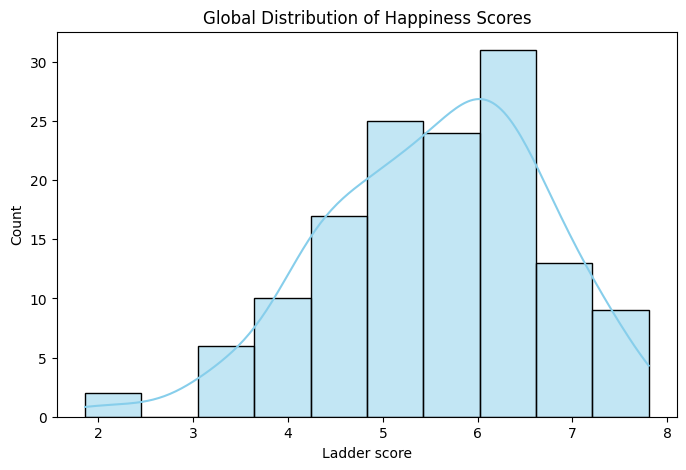

Skewness of Happiness Score: -0.4568752925499331


In [14]:
# Distribution of Happiness Scores
plt.figure(figsize=(8, 5))
sns.histplot(df['Ladder score'], kde=True, color='skyblue')
plt.title('Global Distribution of Happiness Scores')
plt.show()

# Checking for skewness
print(f"Skewness of Happiness Score: {df['Ladder score'].skew()}")

In [15]:
# Select features based on high correlation with Ladder score
features = ['Logged GDP per capita', 'Social support', 'Healthy life expectancy', 
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

X = df[features]
y = df['Ladder score']

In [16]:
from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split successful. Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}")

Data split successful. Training rows: 109, Testing rows: 28


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load the data
df = pd.read_csv('worldhappiness.csv')

# 2. FIX THE VALUE ERROR: Drop rows with missing values (NaN)
# This ensures every row used for training is complete.
df = df.dropna(subset=['Logged GDP per capita', 'Social support', 'Healthy life expectancy', 
                       'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 
                       'Ladder score'])

# 3. Prepare Data
X = df[['Logged GDP per capita', 'Social support', 'Healthy life expectancy', 
        'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']]
y = df['Ladder score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "Model": name, 
        "MAE": mean_absolute_error(y_test, preds), 
        "R2": r2_score(y_test, preds)
    })

# 5. Create Table and Save CSV
comparison_table = pd.DataFrame(results)
comparison_table.to_csv('model_metrics.csv', index=False)

print("Success! Missing values removed, models trained, and model_metrics.csv saved.")
comparison_table

Success! Missing values removed, models trained, and model_metrics.csv saved.


,Model,MAE,R2
0,Linear Regression,0.283957,0.874209
1,Random Forest,0.291439,0.841070
2,Gradient Boosting,0.307933,0.809663


In [24]:
# 1. Train the models and create the 'results' list
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "Model": name, 
        "MAE": mean_absolute_error(y_test, preds), 
        "R2": r2_score(y_test, preds)
    })

# 2. THIS IS THE LINE YOU ARE MISSING:
comparison_table = pd.DataFrame(results)
comparison_table

,Model,MAE,R2
0,Linear Regression,0.283957,0.874209
1,Random Forest,0.291439,0.841070
2,Gradient Boosting,0.307933,0.809663


In [25]:
# Save the comparison table as your Model Metrics file
comparison_table.to_csv('model_metrics.csv', index=False)
print("Model metrics file saved successfully!")

Model metrics file saved successfully!


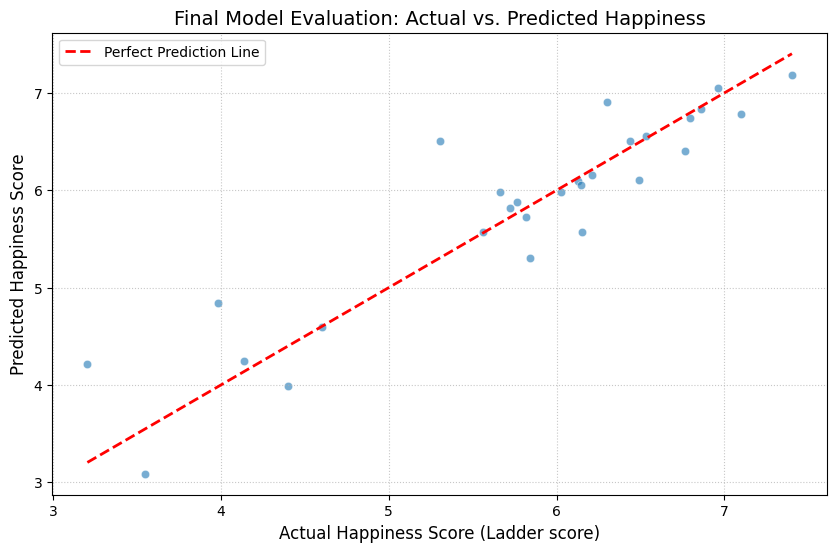

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the best model to make final predictions on the test set
# Replace 'Random Forest' with whichever model had the best MAE in your table
final_model = models["Random Forest"]
y_pred = final_model.predict(X_test)

# 2. Create the Actual vs. Predicted Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# 3. Add a 45-degree line to show what a "perfect" prediction would look like
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')

# 4. Add clear labels and title (Rubric Requirement)
plt.xlabel('Actual Happiness Score (Ladder score)', fontsize=12)
plt.ylabel('Predicted Happiness Score', fontsize=12)
plt.title('Final Model Evaluation: Actual vs. Predicted Happiness', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 5. Save the figure for your project report/GitHub
plt.savefig('actual_vs_predicted.png')
plt.show()

/var/folders/b4/8pqxh51x36l1mzkf61g7840r0000gn/T/ipykernel_15123/1921955247.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


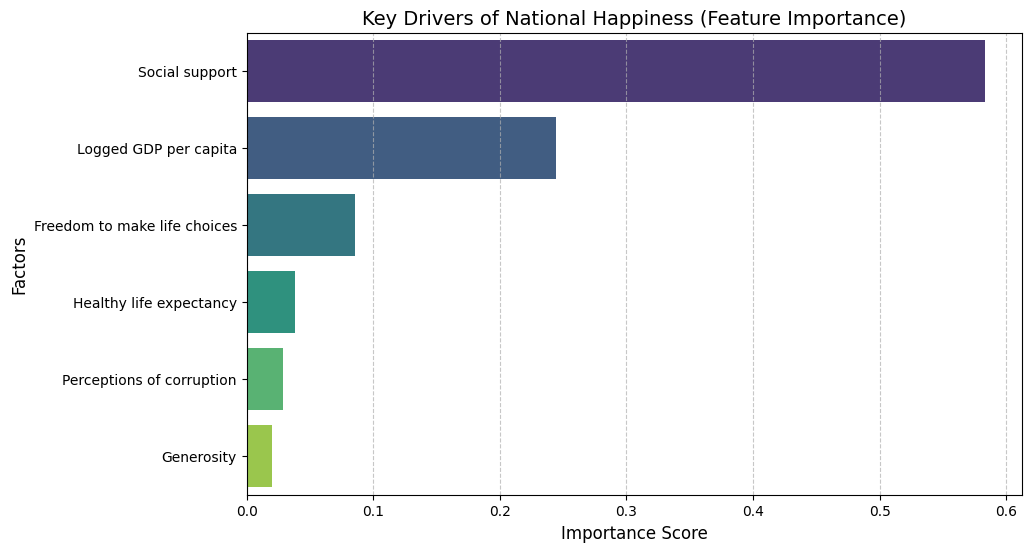

In [27]:
# 1. Get feature importance from your best model (Random Forest)
importances = final_model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot the Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# 4. Add labels and title for the rubric
plt.title('Key Drivers of National Happiness (Feature Importance)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Factors', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 5. Save the figure for your report
plt.savefig('feature_importance.png')
plt.show()